In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [92]:
df = pd.read_csv("Titanic-Dataset.csv")

In [93]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [94]:
df.shape

(891, 12)

In [95]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [97]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [98]:
# Handle missing values

# Fill missing Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin because most values are missing
df = df.drop(columns=['Cabin'])

# Check missing values again
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [99]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [100]:
# Check categorical columns

df.select_dtypes(include='object').columns

Index(['Name', 'Sex', 'Ticket', 'Embarked'], dtype='object')

In [101]:
# Encode Sex column

df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,S


In [102]:
# One-hot encode Embarked

df = pd.get_dummies(df, columns=['Embarked'], dtype=int)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,0,0,1
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,0,0,1


In [103]:
# Remove text columns

df = df.drop(columns=['Name', 'Ticket'])

df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,0,22.0,1,0,7.2500,0,0,1
1,2,1,1,1,38.0,1,0,71.2833,1,0,0
2,3,1,3,1,26.0,0,0,7.9250,0,0,1
3,4,1,1,1,35.0,1,0,53.1000,0,0,1
4,5,0,3,0,35.0,0,0,8.0500,0,0,1


In [104]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Fare', 'Embarked_C', 'Embarked_Q', 'Embarked_S'],
      dtype='object')

In [105]:
from sklearn.preprocessing import StandardScaler

# Select numerical columns to scale
features_to_scale = ['Age', 'Fare', 'SibSp', 'Parch']

# Create scaler
scaler = StandardScaler()

# Apply scaling
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

# Display the result
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,0,-0.565736,0.432793,-0.473674,-0.502445,0,0,1
1,2,1,1,1,0.663861,0.432793,-0.473674,0.786845,1,0,0
2,3,1,3,1,-0.258337,-0.474545,-0.473674,-0.488854,0,0,1
3,4,1,1,1,0.433312,0.432793,-0.473674,0.420730,0,0,1
4,5,0,3,0,0.433312,-0.474545,-0.473674,-0.486337,0,0,1


In [106]:
df.describe()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
count,891.000000,891.000000,891.000000,891.000000,8.910000e+02,8.910000e+02,8.910000e+02,8.910000e+02,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,0.352413,2.272780e-16,4.386066e-17,5.382900e-17,3.987333e-18,0.188552,0.086420,0.725028
std,257.353842,0.486592,0.836071,0.477990,1.000562e+00,1.000562e+00,1.000562e+00,1.000562e+00,0.391372,0.281141,0.446751
min,1.000000,0.000000,1.000000,0.000000,-2.224156e+00,-4.745452e-01,-4.736736e-01,-6.484217e-01,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,0.000000,-5.657365e-01,-4.745452e-01,-4.736736e-01,-4.891482e-01,0.000000,0.000000,0.000000
50%,446.000000,0.000000,3.000000,0.000000,-1.046374e-01,-4.745452e-01,-4.736736e-01,-3.573909e-01,0.000000,0.000000,1.000000
75%,668.500000,1.000000,3.000000,1.000000,4.333115e-01,4.327934e-01,-4.736736e-01,-2.424635e-02,0.000000,0.000000,1.000000
max,891.000000,1.000000,3.000000,1.000000,3.891554e+00,6.784163e+00,6.974147e+00,9.667167e+00,1.000000,1.000000,1.000000


In [107]:
# Detect outliers using IQR

Q1 = df[['Age', 'Fare', 'SibSp', 'Parch']].quantile(0.25)
Q3 = df[['Age', 'Fare', 'SibSp', 'Parch']].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (
    (df[['Age', 'Fare', 'SibSp', 'Parch']] < lower_bound) |
    (df[['Age', 'Fare', 'SibSp', 'Parch']] > upper_bound)
)

outliers.sum()

Age       66
Fare     116
SibSp     46
Parch    213
dtype: int64

In [108]:
# Remove outliers using IQR

df = df[
    ~(
        (df['Age'] < lower_bound['Age']) |
        (df['Age'] > upper_bound['Age']) |
        (df['Fare'] < lower_bound['Fare']) |
        (df['Fare'] > upper_bound['Fare']) |
        (df['SibSp'] < lower_bound['SibSp']) |
        (df['SibSp'] > upper_bound['SibSp']) |
        (df['Parch'] < lower_bound['Parch']) |
        (df['Parch'] > upper_bound['Parch'])
    )
]

df.shape

(577, 11)

In [109]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked_C     0
Embarked_Q     0
Embarked_S     0
dtype: int64

In [110]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Sex              int64
Age            float64
SibSp          float64
Parch          float64
Fare           float64
Embarked_C       int64
Embarked_Q       int64
Embarked_S       int64
dtype: object

In [111]:
df.shape

(577, 11)

In [112]:
df.head(10)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,0,-0.565736,0.432793,-0.473674,-0.502445,0,0,1
2,3,1,3,1,-0.258337,-0.474545,-0.473674,-0.488854,0,0,1
3,4,1,1,1,0.433312,0.432793,-0.473674,0.420730,0,0,1
4,5,0,3,0,0.433312,-0.474545,-0.473674,-0.486337,0,0,1
5,6,0,3,0,-0.104637,-0.474545,-0.473674,-0.478116,0,1,0
6,7,0,1,0,1.893459,-0.474545,-0.473674,0.395814,0,0,1
9,10,1,2,1,-1.180535,0.432793,-0.473674,-0.042956,1,0,0
12,13,0,3,0,-0.719436,-0.474545,-0.473674,-0.486337,0,0,1
14,15,0,3,1,-1.180535,-0.474545,-0.473674,-0.490280,0,0,1
17,18,1,2,0,-0.104637,-0.474545,-0.473674,-0.386671,0,0,1


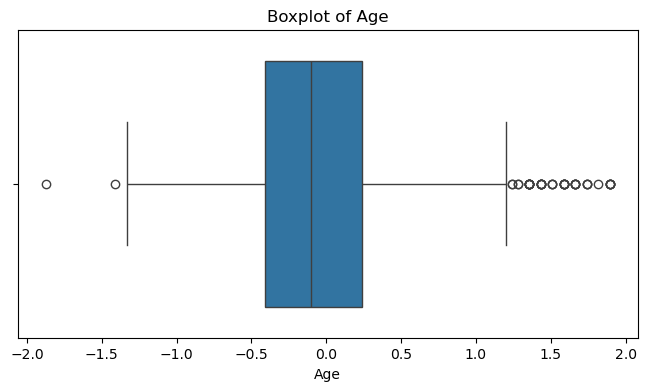

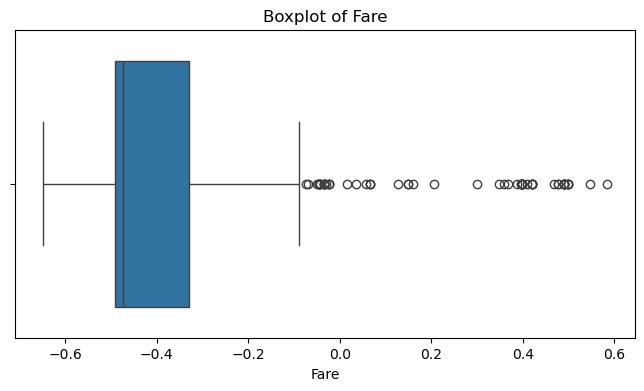

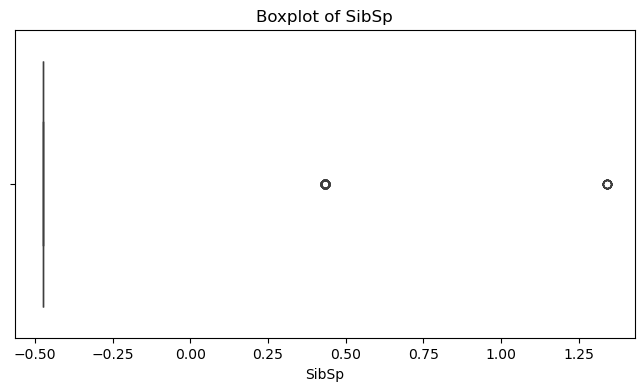

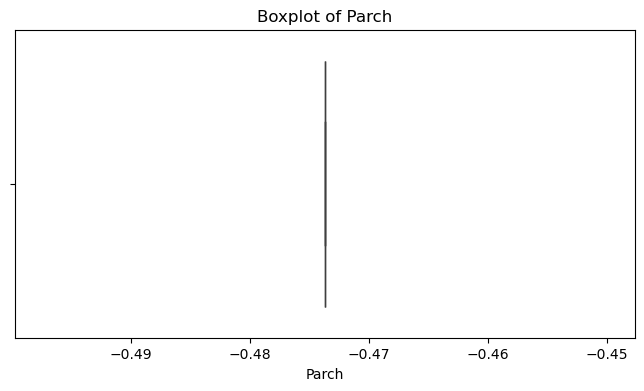

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize outliers using boxplots

columns = ['Age', 'Fare', 'SibSp', 'Parch']

for column in columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot of {column}')
    plt.show()

# Task 1: Data Cleaning and Preprocessing

## Steps Performed

1. Loaded the Titanic dataset.
2. Inspected the dataset structure and data types.
3. Checked for missing values.
4. Filled missing Age values using the median.
5. Filled missing Embarked values using the mode.
6. Removed the Cabin column due to a large number of missing values.
7. Encoded the Sex column into numerical values.
8. Applied one-hot encoding to the Embarked column.
9. Removed unnecessary text columns such as Name and Ticket.
10. Applied StandardScaler to selected numerical features.
11. Detected outliers using the IQR method.
12. Removed detected outliers.
13. Performed final validation of the cleaned dataset.

## Result

The dataset is now cleaned and converted into a numerical format suitable for machine learning preprocessing.